# Group-Structured World Model: Demo

The synthetic environment has state `(orientation, has_key)`:

- `orientation in {0,1,2,3}` -- a Z4 rotation
- `has_key in {0,1}`

and three actions: `turn_left`, `turn_right` (inverse rotations generating Z4),
and `pick_up` (idempotent, non-invertible).

This notebook loads a checkpoint trained with `python train.py`, and inspects
what the model actually learned: the per-action gates, the operators `W_a`,
and a short predicted rollout. Run `python train.py` first if `../checkpoint.pt`
does not exist yet.

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import torch
import matplotlib.pyplot as plt

from src.environment import ACTION_NAMES, N_ACTIONS, OBS_DIM, sample_trajectories
from src.model import WorldModel

ckpt = torch.load("../checkpoint.pt", map_location="cpu")
model = WorldModel(obs_dim=OBS_DIM, latent_dim=ckpt["latent_dim"], n_actions=N_ACTIONS)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()
print("Loaded model with latent_dim =", ckpt["latent_dim"])

Loaded model with latent_dim = 8


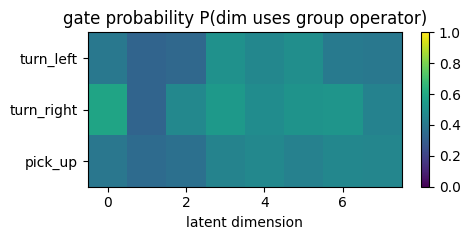

In [2]:
# Per-(action, dimension) gate probabilities: 1 = routed through the group
# operator W_a, 0 = routed through the free residual network.
gate_p = model.transition.gate_probs().detach().numpy()

fig, ax = plt.subplots(figsize=(5, 2.5))
im = ax.imshow(gate_p, vmin=0, vmax=1, cmap="viridis", aspect="auto")
ax.set_yticks(range(len(ACTION_NAMES)))
ax.set_yticklabels(ACTION_NAMES)
ax.set_xlabel("latent dimension")
ax.set_title("gate probability P(dim uses group operator)")
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

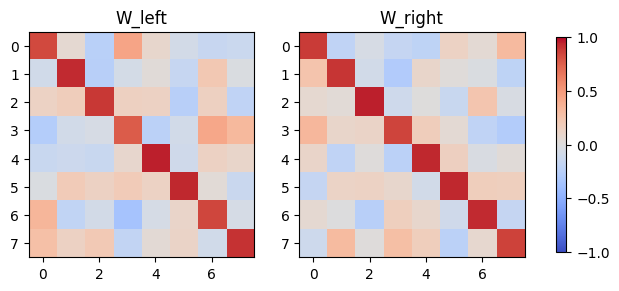

In [3]:
# The learned rotation operators W_left, W_right.
with torch.no_grad():
    W = model.transition.W()

left, right = ACTION_NAMES.index("turn_left"), ACTION_NAMES.index("turn_right")

fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))
for ax, name, idx in zip(axes, ["W_left", "W_right"], [left, right]):
    im = ax.imshow(W[idx].numpy(), cmap="coolwarm", vmin=-1, vmax=1)
    ax.set_title(name)
fig.colorbar(im, ax=axes, shrink=0.8)
plt.show()

In [4]:
# Algebraic checks: is turn_left close to order 4? Is turn_right its inverse?
D = W.shape[-1]
I = torch.eye(D)

w4 = torch.linalg.matrix_power(W[left], 4)
print("||W_left^4 - I|| =", (w4 - I).norm().item())

inv_err = (W[right] @ W[left] - I).norm().item()
print("||W_right @ W_left - I|| =", inv_err)

||W_left^4 - I|| = 3.636258125305176
||W_right @ W_left - I|| = 1.3980997800827026


In [5]:
# A short predicted rollout vs. ground truth.
rng = np.random.default_rng(0)
obs, actions = sample_trajectories(batch_size=1, horizon=6, rng=rng)

with torch.no_grad():
    preds = model.rollout(obs[:, 0], actions)

print(f"{'step':>4} {'action':<12} {'predicted':<28} {'true'}")
for t in range(actions.shape[1]):
    a_name = ACTION_NAMES[actions[0, t].item()]
    pred = preds[t][0].round().tolist()
    true = obs[0, t + 1].tolist()
    print(f"{t:>4} {a_name:<12} {str(pred):<28} {true}")

step action       predicted                    true
   0 turn_right   [1.0, -0.0, 0.0, 0.0, 1.0]   [1.0, 0.0, 0.0, 0.0, 1.0]
   1 turn_left    [-0.0, -0.0, 0.0, 1.0, 1.0]  [0.0, 0.0, 0.0, 1.0, 1.0]
   2 turn_left    [-0.0, 0.0, 1.0, -0.0, 1.0]  [0.0, 0.0, 1.0, 0.0, 1.0]
   3 turn_left    [0.0, 1.0, 0.0, -0.0, 1.0]   [0.0, 1.0, 0.0, 0.0, 1.0]
   4 turn_left    [1.0, 0.0, -0.0, 0.0, 1.0]   [1.0, 0.0, 0.0, 0.0, 1.0]
   5 turn_left    [-0.0, -0.0, 0.0, 1.0, 1.0]  [0.0, 0.0, 0.0, 1.0, 1.0]
